In [1]:
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)

import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/train.csv
/kaggle/input/test.csv
/kaggle/input/description.md
/kaggle/input/sample_submission.csv
/kaggle/input/train.csv.zip
/kaggle/input/test.csv.zip
/kaggle/input/sample_submission.csv.zip
/kaggle/input/tweet-sentiment-extraction/train.csv
/kaggle/input/tweet-sentiment-extraction/test.csv
/kaggle/input/tweet-sentiment-extraction/description.md
/kaggle/input/tweet-sentiment-extraction/sample_submission.csv
/kaggle/input/tweet-sentiment-extraction/train.csv.zip
/kaggle/input/tweet-sentiment-extraction/test.csv.zip
/kaggle/input/tweet-sentiment-extraction/sample_submission.csv.zip


In [2]:
train_df = pd.read_csv("/kaggle/input/tweet-sentiment-extraction/train.csv")
train_df.head(5)



,textID,text,selected_text,sentiment
0,8d4ad58b45,eating breakfast getting ready to go to schoo...,eating breakfast getting ready to go to schoo...,negative
1,fdfe12a800,Going to fold laundry and then hit the sack. I...,I have boring saturday evenings,negative
2,5efd224f4e,happy mothers day to all im off to spend the...,happy,positive
3,5678f1f769,one of my favorite quotes ever,favorite,positive
4,706510b794,"yeah, that was my point >.< please dont make ...",worse,negative


In [3]:
train_df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24732 entries, 0 to 24731
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         24732 non-null  object
 1   text           24731 non-null  object
 2   selected_text  24731 non-null  object
 3   sentiment      24732 non-null  object
dtypes: object(4)
memory usage: 773.0+ KB


In [4]:
train_df.dropna(inplace=True)




In [5]:
def jacquard_f(text1, text2):
    text1 = set(str(text1).lower().split())
    text2 = set(str(text2).lower().split())
    inter = text1.intersection(text2)
    denom = len(text1) + len(text2) - len(inter)
    return len(inter) / denom if denom != 0 else 0.0




In [6]:
# NOTE: Keep the user's feature engineering logic, but fix the merge bug that created
# selected_text_x/selected_text_y and inflated rows. We compute jac directly on the same rows.
train_df["jac"] = train_df.apply(
    lambda r: jacquard_f(r["text"], r["selected_text"]), axis=1
)
train_df.head(3)



,textID,text,selected_text,sentiment,jac
0,8d4ad58b45,eating breakfast getting ready to go to schoo...,eating breakfast getting ready to go to schoo...,negative,1.000000
1,fdfe12a800,Going to fold laundry and then hit the sack. I...,I have boring saturday evenings,negative,0.357143
2,5efd224f4e,happy mothers day to all im off to spend the...,happy,positive,0.083333


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


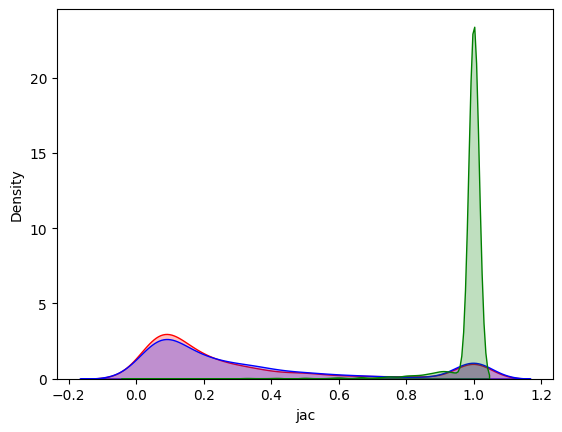

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

p1 = sns.kdeplot(
    train_df[train_df["sentiment"] == "positive"]["jac"], fill=True, color="r"
)
p2 = sns.kdeplot(
    train_df[train_df["sentiment"] == "negative"]["jac"], fill=True, color="b"
)
p3 = sns.kdeplot(
    train_df[train_df["sentiment"] == "neutral"]["jac"], fill=True, color="g"
)



In [8]:
train_df["num_words_text"] = train_df["text"].apply(lambda x: len(str(x).split()))



In [9]:
# BUGFIX: pandas>=2.x groupby.mean() on mixed dtypes can error; aggregate numeric column only.
less_three = train_df[train_df["num_words_text"] <= 2]
less_three.groupby("sentiment")["jac"].mean()
less_three.head(5)



,textID,text,selected_text,sentiment,jac,num_words_text
53,6bc29f134a,Sounds Fun!,Sounds Fun!,positive,1.0,2
73,6824c44c21,me neither,me neither,neutral,1.0,2
169,5714d8c2c3,Goodnight.,Goodnight,positive,0.0,1
176,3113132bb5,thanks lyxxx,thanks,positive,0.5,2
180,f50755906e,eat (cup)cake,eat (cup)cake,neutral,1.0,2


In [10]:
# BUGFIX: NLTK stopwords may not be available offline. Fallback to a small built-in set if missing.
from nltk.corpus import stopwords as _nltk_stopwords

try:
    stopword = _nltk_stopwords.words("english")
except LookupError:
    stopword = {
        "a",
        "an",
        "the",
        "and",
        "or",
        "but",
        "if",
        "while",
        "is",
        "am",
        "are",
        "was",
        "were",
        "be",
        "been",
        "being",
        "to",
        "of",
        "in",
        "for",
        "on",
        "with",
        "as",
        "by",
        "at",
        "from",
        "up",
        "down",
        "out",
        "over",
        "under",
        "this",
        "that",
        "these",
        "those",
        "it",
        "its",
        "i",
        "me",
        "my",
        "we",
        "our",
        "you",
        "your",
        "he",
        "him",
        "his",
        "she",
        "her",
        "they",
        "them",
        "their",
        "what",
        "which",
        "who",
        "whom",
        "why",
        "how",
        "not",
        "no",
        "so",
        "too",
        "very",
    }



In [11]:
import re
import string


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\[.*?\]", "", text)
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = re.sub(r"<.*?>+", "", text)
    text = re.sub(r"[%s]" % re.escape(string.punctuation), "", text)
    text = re.sub(r"\n", "", text)
    text = re.sub(r"\w*\d\w*", "", text)
    text = text.split()
    words = [t for t in text if t not in stopword]
    return words


train_df["list_words"] = train_df["text"].apply(lambda x: clean_text(x))
train_df["list_words_selected"] = train_df["selected_text"].apply(
    lambda x: clean_text(x)
)



In [12]:
train_df["list_words"].head(3)



0      [eating, breakfast, getting, ready, go, school]
1    [going, fold, laundry, hit, sack, boring, satu...
2        [happy, mothers, day, im, spend, day, family]
Name: list_words, dtype: object

In [13]:
from collections import Counter

top_words_text = Counter(
    [item for sublist in train_df["list_words"] for item in sublist]
)
top_words_selected_text = Counter(
    [item for sublist in train_df["list_words_selected"] for item in sublist]
)



In [14]:
positives = train_df[train_df["sentiment"] == "positive"]
negatives = train_df[train_df["sentiment"] == "negative"]
neutrals = train_df[train_df["sentiment"] == "neutral"]



In [15]:
top = Counter([item for sublist in positives["list_words"] for item in sublist])
temp_positive = pd.DataFrame(top.most_common(20))
temp_positive.columns = ["Common_words", "count"]
temp_positive



,Common_words,count
0,day,1097
1,good,948
2,love,767
3,happy,758
4,im,662
5,mothers,557
6,thanks,504
7,great,414
8,like,375
9,hope,357


In [16]:
top = Counter([item for sublist in negatives["list_words"] for item in sublist])
temp_negative = pd.DataFrame(top.most_common(20))
temp_negative.columns = ["Common_words", "count"]
temp_negative



,Common_words,count
0,im,1127
1,like,429
2,cant,422
3,dont,420
4,get,395
5,miss,379
6,sad,353
7,go,348
8,work,344
9,sorry,308


In [17]:
top = Counter([item for sublist in neutrals["list_words"] for item in sublist])
temp_neutral = pd.DataFrame(top.most_common(20))
temp_neutral.columns = ["Common_words", "count"]
temp_neutral



,Common_words,count
0,im,916
1,get,560
2,go,527
3,day,456
4,dont,442
5,work,434
6,going,426
7,like,413
8,got,407
9,lol,404


In [18]:
import plotly.express as px

fig = px.treemap(
    temp_positive, path=["Common_words"], values="count", title="Common Postive Words"
)
fig.show()
fig = px.treemap(
    temp_negative, path=["Common_words"], values="count", title="Common Negative Words"
)
fig.show()
fig = px.treemap(
    temp_neutral, path=["Common_words"], values="count", title="Common Neutral Words"
)
fig.show()




In [19]:
def get_unique_words(sentiment, numwords, raw_words):
    other_words = []
    for item in train_df[train_df.sentiment != sentiment]["list_words"]:
        for word in item:
            other_words.append(word)
    other_words = list(set(other_words))
    category_words = [x for x in raw_words if x not in other_words]
    newcounter = Counter()
    for item in train_df[train_df.sentiment == sentiment]["list_words"]:
        for word in item:
            newcounter[word] += 1
    keep = list(category_words)
    for word in list(newcounter):
        if word not in keep:
            del newcounter[word]
    unique_words = pd.DataFrame(
        newcounter.most_common(numwords), columns=["words", "count"]
    )
    return unique_words




In [20]:
raw_text = [word for word_list in train_df["list_words"] for word in word_list]
unique_positive = get_unique_words("positive", 20, raw_text)
unique_negative = get_unique_words("negative", 20, raw_text)
unique_neutral = get_unique_words("neutral", 20, raw_text)
unique_positive



,words,count
0,congratulations,25
1,appreciated,8
2,lovin,8
3,brilliant,8
4,thnx,8
5,greetings,7
6,presents,7
7,shared,7
8,goood,6
9,blessings,6


In [21]:
# Reload fresh train/test for modeling (as in original code).
train_df = pd.read_csv("/kaggle/input/tweet-sentiment-extraction/train.csv")
test_df = pd.read_csv("/kaggle/input/tweet-sentiment-extraction/test.csv")
train_df["text_length"] = train_df["text"].apply(lambda x: len(str(x).split()))
train_df = train_df[train_df["text_length"] >= 3].copy()
train_df.dropna(inplace=True)




In [22]:
def format_data(sentiment):
    formatted_data = []
    for index, row in train_df.iterrows():
        if row.sentiment == sentiment:
            selected_text = str(row.selected_text)
            text = str(row.text)
            start = text.find(selected_text)
            if start == -1:
                # If the selected_text isn't found (rare due to punctuation/spacing), skip to avoid invalid spans.
                continue
            end = start + len(selected_text)
            formatted_data.append((text, {"entities": [(start, end, "selected_text")]}))
    return formatted_data




In [23]:
# BUGFIX: Update spaCy training to v3 API. Keep same idea: train a blank en NER for each sentiment.
import spacy
from tqdm import tqdm
import random
from spacy.util import minibatch, compounding
from spacy.training import Example


def train(train_data, output_path, n_iter=20, model=None):
    # output_path is a directory path; use it consistently for saving/loading.
    if model is not None:
        nlp = spacy.load(output_path)
    else:
        nlp = spacy.blank("en")

    if "ner" not in nlp.pipe_names:
        ner = nlp.add_pipe("ner", last=True)
    else:
        ner = nlp.get_pipe("ner")

    for _, annotations in train_data:
        for ent in annotations.get("entities"):
            ner.add_label(ent[2])

    other_pipes = [pipe for pipe in nlp.pipe_names if pipe != "ner"]
    with nlp.disable_pipes(*other_pipes):
        # Initialize with examples for correct shapes in spaCy v3+
        examples = []
        for text, ann in train_data[: min(50, len(train_data))]:
            doc = nlp.make_doc(text)
            examples.append(Example.from_dict(doc, ann))
        nlp.initialize(get_examples=lambda: examples)

        for itn in tqdm(range(n_iter)):
            random.shuffle(train_data)
            losses = {}
            batches = minibatch(train_data, size=compounding(4.0, 500.0, 1.001))
            for batch in batches:
                examples = []
                for text, ann in batch:
                    doc = nlp.make_doc(text)
                    examples.append(Example.from_dict(doc, ann))
                nlp.update(examples, drop=0.5, losses=losses)
            print("Losses", losses)

    nlp.meta["name"] = "st_ner"
    nlp.to_disk(output_path)




In [24]:
sentiment = "positive"
train_data_positive = format_data(sentiment)
train(train_data_positive, "./positive", n_iter=3, model=None)



/usr/local/lib/python3.11/dist-packages/spacy/training/iob_utils.py:149: UserWarning:

[W030] Some entities could not be aligned in the text " LOL  I know what ya mean. Watching everyone else ..." with entities "[(25, 118, 'selected_text')]". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.

  0%|          | 0/3 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/thinc/layers/layernorm.py:31: RuntimeWarning:

divide by zero encountered in reciprocal

/usr/local/lib/python3.11/dist-packages/spacy/training/iob_utils.py:149: UserWarning:

[W030] Some entities could not be aligned in the text " Okay, no more driving.  I know... I know... you a..." with entities "[(43, 73, 'selected_text')]". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.

/usr/local/lib/python3.11/dist-pack

Losses {'ner': 11978.593689817653}


 67%|██████▋   | 2/3 [01:19<00:39, 39.50s/it]

Losses {'ner': 10583.994855254881}


100%|██████████| 3/3 [01:57<00:00, 39.21s/it]

Losses {'ner': 10303.435934106777}


In [25]:
sentiment = "negative"
train_data_negative = format_data(sentiment)
train(train_data_negative, "./negative", n_iter=3, model=None)




/usr/local/lib/python3.11/dist-packages/spacy/training/iob_utils.py:149: UserWarning:

[W030] Some entities could not be aligned in the text " ..ok brother...did you change your num and not gi..." with entities "[(76, 93, 'selected_text')]". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.

/usr/local/lib/python3.11/dist-packages/spacy/training/iob_utils.py:149: UserWarning:

[W030] Some entities could not be aligned in the text " are you having any problems sending images from T..." with entities "[(65, 93, 'selected_text')]". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.

/usr/local/lib/python3.11/dist-packages/spacy/training/iob_utils.py:149: UserWarning:

[W030] Some entities could not be aligned in the text "Just got home from work.. My feet are killing me" with entit

Losses {'ner': 11388.543885154602}


 67%|██████▋   | 2/3 [01:20<00:39, 39.40s/it]

Losses {'ner': 10251.2763621931}


100%|██████████| 3/3 [02:02<00:00, 40.77s/it]

Losses {'ner': 9997.586749556254}


In [26]:
def predict_entities(text, model):
    text = str(text)
    doc = model(text)
    ent_array = []
    for ent in doc.ents:
        start = text.find(ent.text)
        end = start + len(ent.text)
        new_int = [start, end, ent.label_]
        if start != -1 and new_int not in ent_array:
            ent_array.append([start, end, ent.label_])
    selected_text = (
        text[ent_array[0][0] : ent_array[0][1]] if len(ent_array) > 0 else text
    )
    return selected_text




In [27]:
predicted_selected_text = []
model_pos = spacy.load("./positive")
model_neg = spacy.load("./negative")

for index, row in test_df.iterrows():
    text = str(row.text)
    if row.sentiment == "neutral" or len(text.split()) <= 2:
        predicted_selected_text.append(text)
    elif row.sentiment == "positive":
        predicted_selected_text.append(predict_entities(text, model_pos))
    else:
        predicted_selected_text.append(predict_entities(text, model_neg))

test_df["selected_text"] = predicted_selected_text
test_df.head(3)



,textID,text,sentiment,selected_text
0,80a1e6bc32,I just saw a shooting star... I made my wish,positive,I just saw a shooting star... I made my wish
1,863097735d,gosh today sucks! i didnt get my tax returns! ...,negative,sucks!
2,264cd5277f,tired and didn`t really have an exciting Satur...,neutral,tired and didn`t really have an exciting Satur...


In [28]:
# BUGFIX: ensure submission is aligned by textID and always has the required columns.
submission_df = pd.read_csv(
    "/kaggle/input/tweet-sentiment-extraction/sample_submission.csv"
)
submission_df = submission_df.merge(
    test_df[["textID", "selected_text"]],
    on="textID",
    how="left",
    suffixes=("", "_pred"),
)
# In case sample has placeholder selected_text, overwrite with predictions
if "selected_text_pred" in submission_df.columns:
    submission_df["selected_text"] = submission_df["selected_text_pred"]
    submission_df.drop(columns=["selected_text_pred"], inplace=True)

# Fill any missing predictions with empty string (shouldn't happen, but keeps file valid)
submission_df["selected_text"] = submission_df["selected_text"].fillna("")

submission_df.to_csv("submission.csv", index=False)
submission_df.head(10)

,textID,selected_text
0,80a1e6bc32,I just saw a shooting star... I made my wish
1,863097735d,sucks!
2,264cd5277f,tired and didn`t really have an exciting Satur...
3,baee1e6ffc,i`ve been eating cheetos all morning..
4,67d06a8dee,haiiii sankQ i`m fineee ima js get a checkup ...
5,7438c9c09a,CONGRATS
6,77a6add433,"loved, but"
7,0f5c867e5d,In weho! They`re are playing a lot of brit
8,02d47f1829,_NJ Oh! I`m only in my 7 I just joined Twitt...
9,7b46dad07f,awww wish I was
